# Part 6 — Building the trading environment (Gymnasium)

> "Most RL failures in trading are environment bugs, not algorithm bugs."

The environment **defines the problem**: what the agent sees, what it can do, what it gets
paid, and how the world responds. A brilliant algorithm on a leaky or unrealistic environment
learns a brilliant way to make fake money. So before deep RL (Part 7) we build the environment
ourselves, piece by piece, with tests at every step.

| Section | Design decision |
|---|---|
| 6.1 | The Gymnasium API contract |
| 6.2 | **State**: feature engineering without look-ahead |
| 6.3 | **Action space**: what exactly can the agent choose? |
| 6.4 | **Position accounting**: carry-over, mark-to-market, costs |
| 6.5 | **Reward**: what exactly is the agent paid for? |
| 6.6 | **Episodes**: starts, lengths, truncation vs termination, train/test separation |
| 6.7 | Assemble `MyOptionsEnv` from scratch |
| 6.8 | The sanity-test suite every trading env needs |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env
import optrl
from optrl import metrics as M
from optrl.strategies import (STRATEGY_NAMES, build_legs, bs_price_scalar, effective_iv,
                              risk_per_contract, entry_cost_per_contract, RISK_BUDGET, MULT)
from optrl.market import TRADING_DAYS
M.set_style()
A = optrl.ACTION_NAMES
market = optrl.load_default_market()
train, test = market.split(0.7)

---
## 6.1 The Gymnasium API contract

**Analogy: a vending machine.** Every vending machine has the same interface: insert coin,
press button, get item plus change. Gymnasium is that standard interface for RL environments,
so *any* algorithm (your DQN, Stable-Baselines3's PPO…) can plug into *any* environment.

```python
obs, info = env.reset(seed=..., options=...)            # start an episode
obs, reward, terminated, truncated, info = env.step(action)
env.observation_space   # what obs look like (shape, bounds)
env.action_space        # what actions are legal
```

* `terminated`: the episode ended **for a real reason inside the MDP** (account blown up).
  The future value really is 0.
* `truncated`: we **stopped the clock** (52 weeks elapsed). The world would have continued,
  so algorithms must still bootstrap from the next state's value. Mixing these two up
  silently biases learning. It's one of the most common bugs.

### The smallest useful env: the weekly selection problem as a Gym env

In [2]:
class WeeklyTableEnv(gym.Env):
    """Contextual-bandit env: each step = one Monday; reward = chosen strategy's weekly P&L."""

    def __init__(self, features: pd.DataFrame, table: pd.DataFrame, episode_len=52):
        super().__init__()
        self.X = ((features - features.mean()) / features.std()).to_numpy(np.float32)
        self.R = table.to_numpy() / 1000
        self.episode_len = episode_len
        self.X = np.clip(self.X, -10, 10)
        self.observation_space = spaces.Box(-10, 10, (self.X.shape[1],), np.float32)
        self.action_space = spaces.Discrete(self.R.shape[1])

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)                       # seeds self.np_random
        self.t0 = self.t = int(self.np_random.integers(0, len(self.X) - self.episode_len))
        return self.X[self.t], {}

    def step(self, action):
        r = float(self.R[self.t, action])
        self.t += 1
        truncated = self.t - self.t0 >= self.episode_len
        return self.X[self.t], r, False, truncated, {}

tbl = optrl.weekly_pnl_table(train)
wenv = WeeklyTableEnv(optrl.decision_features(train, tbl), tbl)
check_env(wenv, skip_render_check=True)
print("WeeklyTableEnv passes gymnasium's check_env ✓")

WeeklyTableEnv passes gymnasium's check_env ✓


That's the whole contract. Everything else in this notebook is about making the *content*
realistic and correct.

---
## 6.2 State design and feature engineering

**Principles** (write them on a sticky note):

1. **Point-in-time.** Every number must be computable at the decision time from past data only.
2. **Scale-free and roughly stationary.** Prefer ratios, ranks and z-scores (IV rank,
   VIX/VIX3M, EMA gap as a % of price) over raw levels (price = 4,500) that drift over the years.
3. **Relevant.** Each feature should relate to *why* some strategy wins (Part 3's table).
4. **Include the agent's own situation.** Current position, days left to expiry, unrealised
   P&L. Without them the state isn't Markov (Part 4) once positions carry over.
5. **Compact.** Every extra feature needs more data to learn. Redundant features add noise.

### Computing the features from raw data
Below is how each market feature is built from raw closes and VIX levels, the same code you'll
use on real data in Part 9. Every operation is *backward-looking*: rolling windows and EWMs
only use the past.

In [3]:
def build_features(close: pd.Series, vix: pd.Series, vix3m: pd.Series, earnings_dates=None) -> pd.DataFrame:
    f = pd.DataFrame(index=close.index)
    f["vix"] = vix
    lo, hi = vix.rolling(252, min_periods=60).min(), vix.rolling(252, min_periods=60).max()
    f["iv_rank"] = ((vix - lo) / (hi - lo) * 100).clip(0, 100)
    f["term_structure"] = vix / vix3m
    ema9, ema20 = close.ewm(span=9, adjust=False).mean(), close.ewm(span=20, adjust=False).mean()
    f["ema_trend"] = (ema9 - ema20) / close * 100
    logret = np.log(close).diff()
    f["rv_iv_spread"] = logret.rolling(20).std() * np.sqrt(252) * 100 - vix
    f["ret_5d"] = (close / close.shift(5) - 1) * 100
    if earnings_dates is not None:                  # trading days until next earnings date
        pos = np.searchsorted(close.index.values, np.asarray(earnings_dates, dtype="datetime64[ns]"))
        nxt = np.full(len(close), 63)
        for i in range(len(close)):
            later = pos[pos >= i]
            nxt[i] = (later[0] - i) if len(later) else 63
        f["days_to_earnings"] = nxt
    return f

raw = market.df
feat = build_features(raw.close, raw.vix, raw.vix3m, raw.index[raw.is_earnings])
cols = ["vix", "iv_rank", "term_structure", "ema_trend", "rv_iv_spread", "ret_5d", "days_to_earnings"]
print("max abs difference vs the package's features:",
      float((feat[cols].iloc[300:] - raw[cols].iloc[300:]).abs().max().max()))

max abs difference vs the package's features: 6.572520305780927e-13


(We skip the first ~year, where the rolling windows are still warming up. After that the two
implementations agree to floating-point precision.)

### 🛠 Exercise 6.2: the truncation test for look-ahead bias
The most reliable leak detector: **compute the features on data truncated at day t, and on the
full data. The value at day t must be identical.** If a feature changes when you add *future*
data, it's peeking.

Write `truncation_test(build, t)` that returns the max absolute difference at row t. Then
break a feature on purpose: add a centred moving average, `close.rolling(11, center=True).mean()`,
a common mistake in charting code, and watch the test catch it.

*Expected:* 0.0 for the correct features, and a non-zero difference for the centred average.
(Careful: on truncated data the centred average at row t is **NaN**, because it needs 5 future
days. A NaN on one side must count as a mismatch, or the test silently passes.)

In [4]:
def truncation_test(build, t):
    # TODO: full = build(raw_full) ; part = build(raw truncated to first t+1 rows); compare row t
    return None

**Solution**

In [5]:
def truncation_test(build, t):
    full = build(raw.close, raw.vix, raw.vix3m)
    part = build(raw.close.iloc[:t + 1], raw.vix.iloc[:t + 1], raw.vix3m.iloc[:t + 1])
    a, b = full.iloc[t].fillna(-999.0), part.iloc[t].fillna(-999.0)      # a NaN on one side is a mismatch too
    return float((a - b).abs().max())

def build_leaky(close, vix, vix3m):
    f = build_features(close, vix, vix3m)
    f["smooth_price_gap"] = close / close.rolling(11, center=True).mean() - 1     # ← peeks 5 days ahead!
    return f

print("correct features:", truncation_test(build_features, 3000))
print("leaky feature:   ", truncation_test(build_leaky, 3000))

correct features: 0.0
leaky feature:    998.997682663407


Make the truncation test a **unit test** that runs every time you change feature code. It
catches leaks that code review misses.

### Normalisation, with training statistics only
Networks like inputs around ±1–3. We z-score each feature with the **training period's** mean
and std, and pass the same `obs_stats` to the test environment. Using test-period statistics
would leak information about the future, such as "VIX will average 22 next year".

---
## 6.3 Action space design

**Analogy.** Designing a car's controls. A steering wheel plus pedals (few, meaningful controls)
is easier to learn than 50 independent levers, even if the levers could in principle do more.

| Design | Example | Pros | Cons |
|---|---|---|---|
| **Discrete target position** ✅ (ours) | 8 actions: "be in strategy k" | simple; hold = repeat the same action; every action always valid | no sizing, one strategy at a time |
| Event actions | open k / hold / close | mirrors a broker's buttons | invalid actions ("close" when flat) need masking |
| MultiDiscrete | (strategy, size ∈ {½, 1, 2}) | adds sizing | 8×3 = 24 combinations, needs more data |
| Continuous weights (Box) | allocate % of risk to each strategy | portfolios of strategies | harder to learn; needs PPO/SAC; must normalise weights |
| Parametric | choose strategy **and** strikes/DTE | full flexibility | now you're designing strategies, which is not our task |

**Our choice.** Target position, `Discrete(8)`. Every action is always legal, "keep holding"
is simply choosing the same action again, and switching costs are handled inside the env. Start
here, and add sizing only when the selector itself works (a capstone extension).

### 🛠 Exercise 6.3
How many discrete actions would you need for (a) strategy × 3 sizes, plus no-trade?
(b) any *pair* of distinct strategies held together, plus single strategies, plus no-trade?
Write the formulas in code. *Expected:* (a) 7·3 + 1 = 22. (b) C(7,2) + 7 + 1 = 29. Combinatorics
explode quickly, which is why continuous "weights" actions exist.

In [6]:
from math import comb
print("(a)", 7 * 3 + 1, " (b)", comb(7, 2) + 7 + 1)

(a) 22  (b) 29


---
## 6.4 Position accounting: carry-over, mark-to-market, costs

When positions live longer than one step, the env must track them like a broker does:

* **Open**: build the legs (strikes from spot and expected move), size to \$1,000 risk, pay
  premium (a debit) or receive it (a credit), and pay commissions plus half the bid-ask spread.
* **Each day**: **mark to market**. Reprice every leg with Black-Scholes at the current spot,
  current IV and remaining time.
* **Close early**: receive the current value, **pay the spread again**.
* **Expiry**: cash-settle at intrinsic value, with no spread to pay.

**Worked example.** Let's walk through one bull put spread, opened with 10 days to expiry.

In [7]:
i = 2000                                            # a day in the training data
S, vix, dte_e = raw.close.iloc[i], raw.vix.iloc[i], raw.days_to_earnings.iloc[i]
DTE = 10
sig = float(effective_iv(vix, DTE, dte_e)); T = DTE / TRADING_DAYS
legs = [(q, k, float(K)) for q, k, K in build_legs("bull_put_spread", S, sig, T)]
prem = [bs_price_scalar(S, K, T, sig, k) for _, k, K in legs]
risk1 = float(risk_per_contract("bull_put_spread", legs, prem, S, sig, T))
contracts = RISK_BUDGET / risk1
credit = -sum(q * p for (q, _, _), p in zip(legs, prem)) * MULT
cost = float(entry_cost_per_contract(prem)) * contracts
print(f"S={S:.2f}  VIX={vix:.1f}  σ used={sig:.3f}  expected move over 10d = {S * sig * np.sqrt(T):.2f}")
for (q, k, K), p in zip(legs, prem):
    print(f"   {'SELL' if q < 0 else 'BUY '} {k} K={K:.2f} @ {p:.3f}")
print(f"credit/contract ${credit:.0f}  max loss/contract ${risk1:.0f}  → {contracts:.2f} contracts for $1,000 risk")
print(f"entry cost (commission + half-spread) ${cost:.2f}")

for d in [0, 5, 10]:
    j = i + d; days_left = DTE - d
    if days_left > 0:
        s_ = float(effective_iv(raw.vix.iloc[j], days_left, raw.days_to_earnings.iloc[j]))
        val = sum(q * bs_price_scalar(raw.close.iloc[j], K, days_left / TRADING_DAYS, s_, k) for q, k, K in legs)
    else:
        val = sum(q * (max(raw.close.iloc[j] - K, 0) if k == "C" else max(K - raw.close.iloc[j], 0)) for q, k, K in legs)
    print(f"day +{d:2d}: S={raw.close.iloc[j]:.2f}  position value ${val * MULT * contracts:8.1f}  "
          f"unrealised P&L ${(val * MULT + credit) * contracts:7.1f}")

S=106.38  VIX=17.9  σ used=0.179  expected move over 10d = 3.79
   SELL P K=104.25 @ 0.667
   BUY  P K=100.53 @ 0.088
credit/contract $58  max loss/contract $314  → 3.18 contracts for $1,000 risk
entry cost (commission + half-spread) $13.68
day + 0: S=106.38  position value $  -184.2  unrealised P&L $    0.0
day + 5: S=105.73  position value $  -183.4  unrealised P&L $    0.8
day +10: S=105.54  position value $     0.0  unrealised P&L $  184.2


The position value starts at minus the credit (we owe the short put). Theta and price moves
pull it toward 0 if the spread expires worthless. Every number above is what the environment
computes internally at each step.

---
## 6.5 Reward design

**Analogy.** Pay a salesperson only on *closed* deals and they'll never admit a deal is dead:
they'll keep it open forever. Pay them on the *pipeline's current value* and they manage it
honestly.

| Reward choice | Signal | Danger |
|---|---|---|
| **Δ mark-to-market equity** ✅ | every step, dense | depends on the pricing model's accuracy |
| Realised P&L only (on close) | sparse, delayed | **reward hacking**: the agent learns never to close losers |
| Δ equity − λ·(Δ equity)² | penalises big swings | λ too high → sits in cash (Part 1) |
| Δ equity − κ·(increase in drawdown) | penalises new lows | extra state needed (the high-water mark) |
| Sharpe per episode | what you report | one number per episode → very slow learning |

**Our reward.** Δ equity over the step, *including every cost paid*, divided by \$1,000,
with an optional `risk_penalty` λ. Costs sit *inside* the reward, so the agent directly feels
the price of switching.

### 🛠 Exercise 6.5: realised-only rewards invite hacking
Using the environment's trace, compare cumulative **mark-to-market** reward with a
**realised-only** version (P&L credited only when a position closes or expires) for a policy
that opens a short straddle and just holds. *Expected:* the totals match at the end once
everything has been closed, but the realised version is zero for long stretches and then
arrives in lumps. That's a much harder credit-assignment problem, and it lets an agent
"hide" losses by never closing.

In [8]:
env = optrl.OptionsSelectionEnv(train, seed=0, episode_len=20)
obs, info = env.reset(seed=1)
mtm, realised, eq_prev, open_val = [], [], 0.0, None
for t in range(20):
    obs, r, term, trunc, info = env.step(1)                  # keep choosing short_straddle
    mtm.append(info["pnl"])
    # TODO: build the realised-only series. Hint: realised P&L arrives when info["position"] goes
    # from short_straddle to no_trade (expiry). Accumulate MTM P&L while open and release it then.

**Solution**

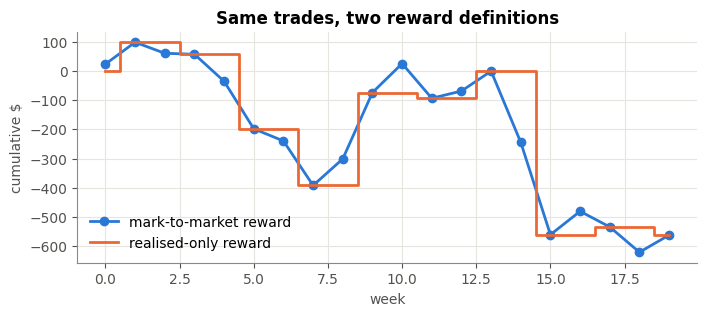

In [9]:
env = optrl.OptionsSelectionEnv(train, seed=0, episode_len=20)
obs, info = env.reset(seed=1)
mtm, realised, pending = [], [], 0.0
for t in range(20):
    obs, r, term, trunc, info = env.step(1)
    mtm.append(info["pnl"]); pending += info["pnl"]
    if info["position"] == "no_trade":                        # the position just expired → realise
        realised.append(pending); pending = 0.0
    else:
        realised.append(0.0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.cumsum(mtm), marker="o", label="mark-to-market reward", color=M.PALETTE[0])
ax.step(range(20), np.cumsum(realised), where="mid", label="realised-only reward", color=M.PALETTE[1])
ax.set_xlabel("week"); ax.set_ylabel("cumulative $"); ax.set_title("Same trades, two reward definitions"); ax.legend(); plt.show()

---
## 6.6 Episode design

* **Random starts.** Each episode begins at a random Monday, so the agent sees many market
  situations and doesn't memorise one path.
* **Length.** 52 weekly steps. Long enough for positions and regimes to play out, short enough
  for many episodes.
* **Truncated, not terminated**, at 52 weeks: the market goes on. (You *would* use
  `terminated=True` for, say, a hard account stop-out.)
* **Train/test separation is built into the env.** You construct one env on the training
  market and another on the test market, sharing `obs_stats` from training. The agent can't
  touch test data during training.

---
## 6.7 Assemble `MyOptionsEnv` from scratch

Now put it all together, in ~90 lines. Read it top to bottom. Every line maps to a decision
above.

In [10]:
class MyOptionsEnv(gym.Env):
    """Weekly strategy selection with 2-week options, carry-over and costs."""

    def __init__(self, market, features=optrl.MarketData.FEATURES, step_days=5, dte=10,
                 episode_len=52, obs_stats=None, risk_penalty=0.0):
        super().__init__()
        d = market.df
        self.S, self.vix = d.close.to_numpy(float), d.vix.to_numpy(float)
        self.dte_earn, self.dow = d.days_to_earnings.to_numpy(int), d.dow.to_numpy()
        F = d[list(features)].to_numpy(float)
        mu, sd = obs_stats if obs_stats is not None else (F.mean(0), F.std(0))     # 6.2: train stats
        self.Fz = np.clip(np.nan_to_num((F - mu) / sd), -20, 20)
        self.step_days, self.dte, self.episode_len, self.lam = step_days, dte, episode_len, risk_penalty
        self.nF = len(features)
        # 6.3: target-position action space; obs = features + position one-hot + life left + unrealised
        self.action_space = spaces.Discrete(8)
        self.observation_space = spaces.Box(-20, 20, (self.nF + 10,), np.float32)
        last = max(len(d) - (episode_len * step_days + dte + 2), 1)
        self.starts = np.flatnonzero(self.dow[:last] == 0)                        # Mondays only

    # ---------- 6.4 position accounting
    def _value(self, i):
        if self.pos is None:
            return 0.0
        legs, n, exp = self.pos["legs"], self.pos["n"], self.pos["exp"]
        left = exp - i
        if left <= 0:                                                           # expiry → intrinsic
            v = sum(q * (max(self.S[i] - K, 0) if k == "C" else max(K - self.S[i], 0)) for q, k, K in legs)
        else:
            sig = float(effective_iv(self.vix[i], left, self.dte_earn[i]))
            v = sum(q * bs_price_scalar(self.S[i], K, left / TRADING_DAYS, sig, k) for q, k, K in legs)
        return v * MULT * n

    def _open(self, a, i):
        name = STRATEGY_NAMES[a - 1]
        sig, T = float(effective_iv(self.vix[i], self.dte, self.dte_earn[i])), self.dte / TRADING_DAYS
        legs = [(q, k, float(K)) for q, k, K in build_legs(name, self.S[i], sig, T)]
        prem = [bs_price_scalar(self.S[i], K, T, sig, k) for _, k, K in legs]
        n = RISK_BUDGET / float(risk_per_contract(name, legs, prem, self.S[i], sig, T))
        self.pos = {"a": a, "legs": legs, "n": n, "exp": i + self.dte,
                    "entry": sum(q * p for (q, _, _), p in zip(legs, prem)) * MULT * n}
        self.cash -= self.pos["entry"] + float(entry_cost_per_contract(prem)) * n

    def _close(self, i):
        self.cash += self._value(i)
        left = self.pos["exp"] - i
        if left > 0:                                                            # early exit pays the spread
            sig = float(effective_iv(self.vix[i], left, self.dte_earn[i]))
            prices = [bs_price_scalar(self.S[i], K, left / TRADING_DAYS, sig, k) for _, k, K in self.pos["legs"]]
            self.cash -= float(entry_cost_per_contract(prices)) * self.pos["n"]
        self.pos = None

    # ---------- observation
    def _obs(self):
        oh = np.zeros(8, np.float32); oh[self.pos["a"] if self.pos else 0] = 1
        life = (self.pos["exp"] - self.i) / self.dte if self.pos else 0.0
        unreal = (self._value(self.i) - self.pos["entry"]) / RISK_BUDGET if self.pos else 0.0
        return np.clip(np.concatenate([self.Fz[self.i], oh, [life, unreal]]), -20, 20).astype(np.float32)

    # ---------- 6.1 API
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        start = (options or {}).get("start")
        self.i = int(start) if start is not None else int(self.np_random.choice(self.starts))
        self.t, self.cash, self.pos = 0, 0.0, None
        return self._obs(), {}

    def step(self, action):
        a = int(action); i0 = self.i
        eq0 = self.cash + self._value(i0)
        if a != (self.pos["a"] if self.pos else 0):                             # switch?
            if self.pos: self._close(i0)
            if a != 0: self._open(a, i0)
        for d in range(1, self.step_days + 1):                                  # let the market move
            self.i = i0 + d
            if self.pos and self.i >= self.pos["exp"]:
                self._close(self.i)
        pnl = self.cash + self._value(self.i) - eq0                             # 6.5: Δ equity incl. costs
        r = pnl / RISK_BUDGET
        self.t += 1
        return self._obs(), float(r - self.lam * r * r), False, self.t >= self.episode_len, {"pnl": pnl}

F = optrl.MarketData.FEATURES
stats = (train.df[F].mean().values, train.df[F].std().values)
my_env = MyOptionsEnv(train, obs_stats=stats)
check_env(my_env, skip_render_check=True)
print("MyOptionsEnv passes check_env ✓")

MyOptionsEnv passes check_env ✓


---
## 6.8 The sanity-test suite

Run these every time you touch the environment. Each one has caught real bugs in real projects.

In [11]:
def test_same_as_reference(n_steps=200, seed=0):
    """Our env must produce exactly the same rewards as the reference implementation."""
    ref = optrl.OptionsSelectionEnv(train, obs_stats=stats, episode_len=10**6)
    mine = MyOptionsEnv(train, obs_stats=stats, episode_len=10**6)
    rng = np.random.default_rng(seed)
    start = int(my_env.starts[10])
    o1, _ = ref.reset(options={"start": start}); o2, _ = mine.reset(options={"start": start})
    worst = 0.0
    for _ in range(n_steps):
        a = int(rng.integers(8))
        o1, r1, *_ = ref.step(a); o2, r2, *_ = mine.step(a)
        worst = max(worst, abs(r1 - r2), float(np.abs(o1 - o2).max()))
    return worst

def test_flat_is_zero():
    e = MyOptionsEnv(train, obs_stats=stats); e.reset(seed=0)
    return sum(abs(e.step(0)[1]) for _ in range(52))

def test_matches_pnl_table(n=50):
    """With 1-week options held to expiry, env P&L must equal the weekly P&L table."""
    e = MyOptionsEnv(train, obs_stats=stats, dte=5, step_days=5, episode_len=1)
    worst = 0.0
    for date in tbl.index[20:20 + n]:
        i = train.df.index.get_loc(date)
        for a in range(1, 8):
            e.reset(options={"start": i})
            worst = max(worst, abs(e.step(a)[4]["pnl"] - tbl.loc[date].iloc[a]))
    return worst

def test_costs_hurt():
    """Switching every week must be worse than holding the same strategy."""
    e = MyOptionsEnv(train, obs_stats=stats, episode_len=10**6); total = {}
    for name, seq in [("hold", [3] * 100), ("flip-flop", [3, 2] * 50)]:
        e.reset(options={"start": int(my_env.starts[5])})
        total[name] = sum(e.step(a)[1] for a in seq)
    return total

def test_seed_determinism():
    e1, e2 = MyOptionsEnv(train, obs_stats=stats), MyOptionsEnv(train, obs_stats=stats)
    return np.array_equal(e1.reset(seed=42)[0], e2.reset(seed=42)[0])

print("1. max |difference| vs reference env      :", test_same_as_reference())
print("2. always-flat total reward               :", test_flat_is_zero())
print("3. max |env − P&L table| (1-week options)  :", round(test_matches_pnl_table(), 8))
print("4. hold vs flip-flop total reward          :", {k: round(v, 2) for k, v in test_costs_hurt().items()})
print("5. same seed → same start                 :", test_seed_determinism())

1. max |difference| vs reference env      : 9.159339953157541e-16
2. always-flat total reward               : 0.0
3. max |env − P&L table| (1-week options)  : 0.0
4. hold vs flip-flop total reward          : {'hold': 2.75, 'flip-flop': -0.89}
5. same seed → same start                 : True


### One more: the "cheating oracle" test
Give a policy **future information**: at each step it picks the strategy with the best *actual*
P&L for the coming week (via the P&L table). It should make enormous money. If a cheating
oracle *can't* profit, your rewards aren't wired to outcomes. If a *non-cheating* agent makes
oracle-like money, you have a leak.

In [12]:
tbl_all = optrl.weekly_pnl_table(train)
e = MyOptionsEnv(train, obs_stats=stats, dte=5, step_days=5, episode_len=10**6)
start = int(my_env.starts[0]); e.reset(options={"start": start})
dates = train.df.index
tot_oracle = 0.0
for k in range(300):
    date = dates[e.i]
    a = int(np.argmax(tbl_all.loc[date].values)) if date in tbl_all.index else 0
    tot_oracle += e.step(a)[4]["pnl"]
print(f"cheating oracle over 300 weeks: ${tot_oracle:,.0f}   (≈ ${tot_oracle / 300:,.0f}/week, impossible in reality)")

cheating oracle over 300 weeks: $298,754   (≈ $996/week, impossible in reality)


### 🛠 Exercise 6.8: add an observation feature with a wrapper
Gymnasium **wrappers** let you modify an env without editing it. Write an
`ObservationWrapper` that appends a binary `earnings_in_life` feature: 1 if the next earnings
date falls before the current option's expiry (or within the next 10 days when flat). Update
`observation_space` and pass `check_env`.

*Expected:* observation size goes from 17 to 18, and `check_env` passes.

In [13]:
class EarningsFlag(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        # TODO: enlarge observation_space by one dimension
    def observation(self, obs):
        # TODO: append the flag
        return obs

**Solution**

In [14]:
class EarningsFlag(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        n = env.observation_space.shape[0] + 1
        self.observation_space = spaces.Box(-20, 20, (n,), np.float32)

    def observation(self, obs):
        e = self.env.unwrapped
        horizon = (e.pos["exp"] - e.i) if e.pos else e.dte
        flag = 1.0 if 1 <= e.dte_earn[e.i] <= horizon else 0.0
        return np.append(obs, np.float32(flag)).astype(np.float32)

wrapped = EarningsFlag(MyOptionsEnv(train, obs_stats=stats))
import warnings; warnings.filterwarnings("ignore", message=".*different from the unwrapped.*")
check_env(wrapped, skip_render_check=True)
print("obs shape:", wrapped.reset(seed=0)[0].shape, "✓")

obs shape: (18,) ✓


## Recap: the environment design checklist
- [ ] Gymnasium API; `terminated` vs `truncated` used correctly; `check_env` passes
- [ ] Every feature is point-in-time (**truncation test**) and normalised with **train** stats
- [ ] State includes the agent's own position, time left, and unrealised P&L
- [ ] Action space is small and always valid (target positions)
- [ ] Positions carry over, are marked to market, and pay costs on entry and early exit
- [ ] Reward = Δ equity net of costs (optionally risk-penalised). No realised-only rewards
- [ ] Random starts; separate train and test envs
- [ ] Sanity tests: flat = 0, matches the P&L table, costs hurt switching, seed determinism,
      and the cheating oracle profits

**Next → Part 7:** put a neural network on top of this environment.